In [ ]:
# require: pip install pulp
import pulp as pl

# --- Données ---

# Shifts possibles (4h consécutives)
shifts = ["8-12","9-13","10-14","11-15","12-16","13-17",
          "14-18","15-19","16-20","17-21","18-22","19-23","20-0"]

# Heures de la journée (8h à 23h)
hours  = list(range(8,24))

# Couverture des shifts : quelles heures sont couvertes par chaque shift
shift_hours = {
    "8-12": [8,9,10,11],
    "9-13": [9,10,11,12],
    "10-14":[10,11,12,13],
    "11-15":[11,12,13,14],
    "12-16":[12,13,14,15],
    "13-17":[13,14,15,16],
    "14-18":[14,15,16,17],
    "15-19":[15,16,17,18],
    "16-20":[16,17,18,19],
    "17-21":[17,18,19,20],
    "18-22":[18,19,20,21],
    "19-23":[19,20,21,22],
    "20-0": [20,21,22,23],
}

# delta[(J,h)] = 1 si le shift J couvre l'heure h, 0 sinon
delta = {}
for J in shifts:
    for h in hours:
        delta[(J,h)] = 1 if (J in shift_hours and h in shift_hours[J]) else 0

# Coût par shift
C = { "8-12": 40, "9-13": 40, "10-14":40, "11-15":40, "12-16":40, "13-17":40, 
      "14-18":40, "15-19":44, "16-20":48, "17-21":52,"18-22":56,
      "19-23":56,"20-0":56
}

# Demande par heure
D = {8: 500, 9: 600, 10: 400, 11: 700, 12: 1500, 13: 1800, 14: 1200, 15: 6000,
     16: 800, 17: 900, 18: 2000, 19: 2200, 20: 1800, 21: 1500, 22: 300, 23: 200}

# Nombre total de livreurs disponibles
N = 500

# Capacité par livreur par heure (dictionnaire)
capacity_per_hour = {8: 9, 9: 11, 10: 10, 11: 8, 12: 7, 13: 9, 14: 8, 15: 13, 16: 12, 17: 11, 18: 10, 19: 8, 20: 9, 21: 7, 22: 4, 23: 3}


# --- Modèle ---
prob = pl.LpProblem("ShiftScheduling", pl.LpMinimize)

# Variables : nombre de livreurs par shift
y = {J: pl.LpVariable(f"y_{J}", lowBound=0, cat="Integer") for J in shifts}

# Slack par heure pour garantir faisabilité
u = {h: pl.LpVariable(f"unmet_{h}", lowBound=0, cat="Integer") for h in hours}

# Objectif : coût total des shifts + grosse pénalité pour le manque de colis
BIGPENALTY = 1000
prob += pl.lpSum(C.get(J,0)*y[J] for J in shifts) + BIGPENALTY * pl.lpSum(u[h] for h in hours)

# Contraintes : couverture de la demande par heure avec capacité variable
for h in hours:
    prob += pl.lpSum(delta[(J,h)] * y[J] * capacity_per_hour[h] for J in shifts) + u[h] >= D[h], f"cover_hour_{h}"

# Limite du nombre total de livreurs
prob += pl.lpSum(y[J] for J in shifts) <=2* N, "max_total_drivers"

# Bornes supérieures par shift (impossible d'affecter plus que N livreurs)
for J in shifts:
    prob += y[J] <= N

# --- Résolution ---
prob.solve(pl.PULP_CBC_CMD(msg=True))

# --- Résultats ---
print("Status:", pl.LpStatus[prob.status])
print("Objective:", pl.value(prob.objective))
print("\nNombre de livreurs par shift :")
for J in shifts:
    print(f"{J} -> {int(pl.value(y[J]))}")

print("\nColis livrés par heure :")
for h in hours:
    delivered = sum(delta[(J,h)] * y[J].varValue * capacity_per_hour[h] for J in shifts)
    print(f"Hour {h}: {delivered} colis (Demande: {D[h]})")


Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /opt/homebrew/lib/python3.11/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/ry/yqwb4m311v78_wyjtn9yym7m0000gn/T/7e5d239d07c94196ba5832f395f81812-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/ry/yqwb4m311v78_wyjtn9yym7m0000gn/T/7e5d239d07c94196ba5832f395f81812-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 35 COLUMNS
At line 217 RHS
At line 248 BOUNDS
At line 278 ENDATA
Problem MODEL has 30 rows, 29 columns and 94 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 22133.3 - 0.00 seconds
Cgl0003I 0 fixed, 16 tightened bounds, 0 strengthened rows, 0 substitutions
Cgl0004I processed model has 17 rows, 29 columns (29 integer (0 of which binary)) and 81 elements
Cutoff increment increased from 1e-05 to 0.9999
Cbc0012I Integer solution of 22136 fou

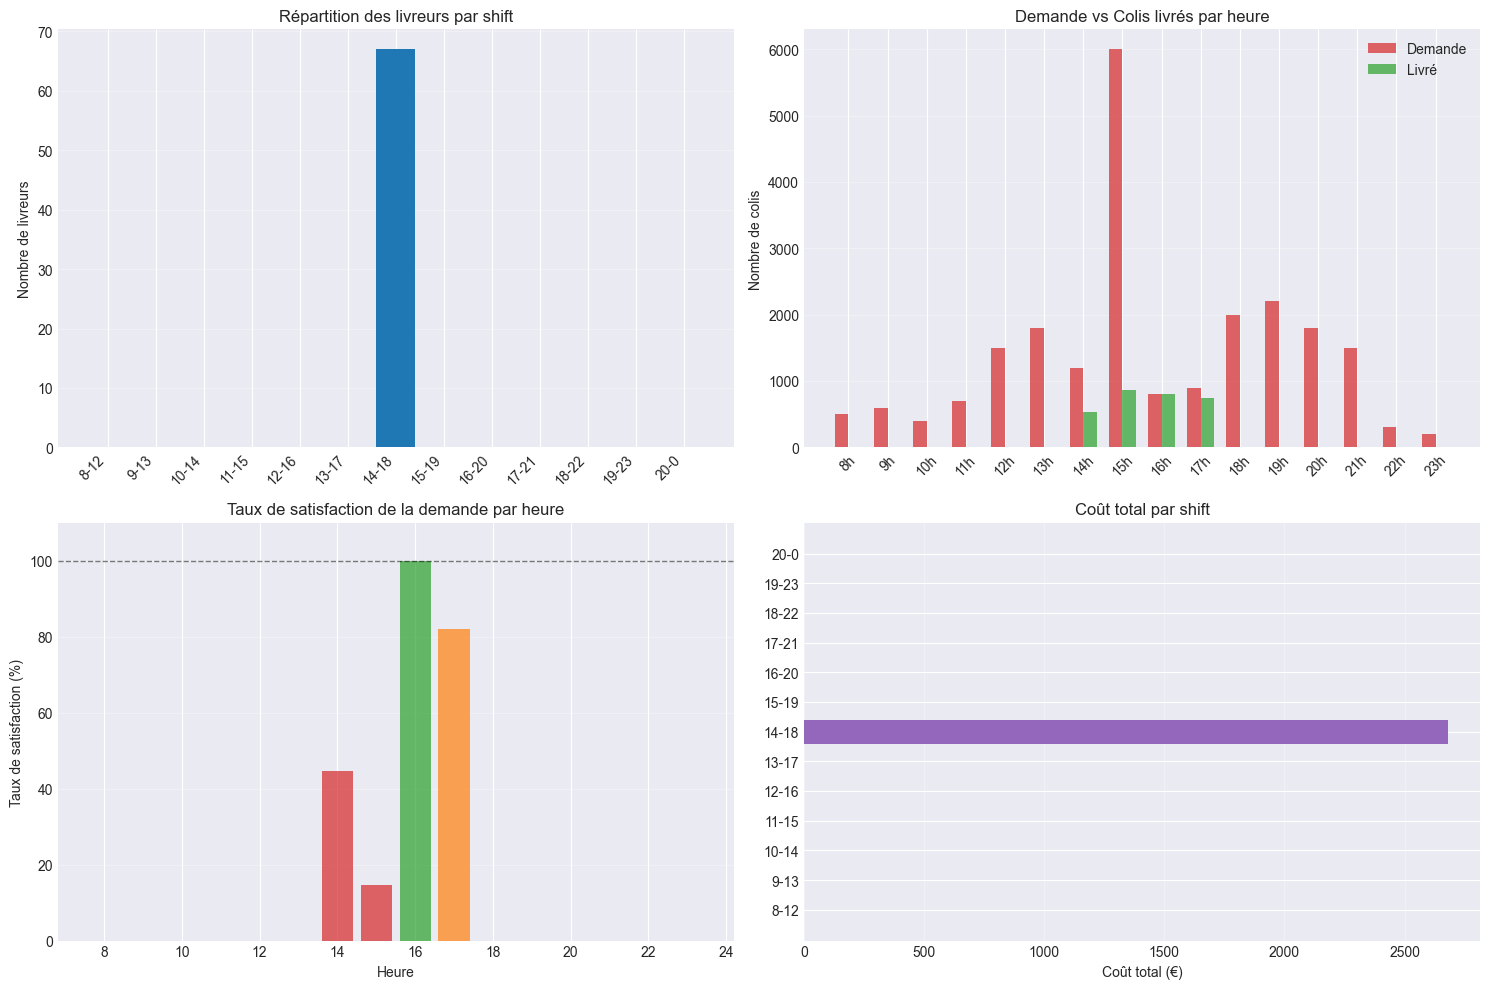


RÉSUMÉ DE L'OPTIMISATION
Coût total: 2680 €
Livreurs utilisés: 67 / 500
Colis totaux livrés: 2948
Demande totale: 22400
Taux global: 13.2%


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Récupérer les résultats
shifts_assigned = {J: int(pl.value(y[J])) for J in shifts}
delivered_per_hour = {}
for h in hours:
    delivered_per_hour[h] = sum(delta[(J,h)] * y[J].varValue * capacity_per_hour[h] for J in shifts)

# Configuration pour de beaux graphiques
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Nombre de livreurs par shift
ax1 = axes[0, 0]
shifts_list = list(shifts_assigned.keys())
counts = list(shifts_assigned.values())
colors = ['#1f77b4' if c < 50 else '#ff7f0e' for c in [C[s] for s in shifts_list]]
ax1.bar(range(len(shifts_list)), counts, color=colors)
ax1.set_xticks(range(len(shifts_list)))
ax1.set_xticklabels(shifts_list, rotation=45, ha='right')
ax1.set_ylabel('Nombre de livreurs')
ax1.set_title('Répartition des livreurs par shift')
ax1.grid(axis='y', alpha=0.3)

# 2. Demande vs Livraisons par heure
ax2 = axes[0, 1]
hours_list = list(hours)
demand = [D[h] for h in hours_list]
delivered = [delivered_per_hour[h] for h in hours_list]
x = np.arange(len(hours_list))
width = 0.35
ax2.bar(x - width/2, demand, width, label='Demande', color='#d62728', alpha=0.7)
ax2.bar(x + width/2, delivered, width, label='Livré', color='#2ca02c', alpha=0.7)
ax2.set_xticks(x)
ax2.set_xticklabels([f"{h}h" for h in hours_list], rotation=45)
ax2.set_ylabel('Nombre de colis')
ax2.set_title('Demande vs Colis livrés par heure')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Taux de satisfaction par heure
ax3 = axes[1, 0]
satisfaction = [min(100, (delivered_per_hour[h] / D[h] * 100)) for h in hours_list]
colors_sat = ['#2ca02c' if s >= 100 else '#ff7f0e' if s >= 80 else '#d62728' for s in satisfaction]
ax3.bar(hours_list, satisfaction, color=colors_sat, alpha=0.7)
ax3.axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax3.set_xlabel('Heure')
ax3.set_ylabel('Taux de satisfaction (%)')
ax3.set_title('Taux de satisfaction de la demande par heure')
ax3.set_ylim(0, 110)
ax3.grid(axis='y', alpha=0.3)

# 4. Coût par shift
ax4 = axes[1, 1]
total_cost_per_shift = {J: C[J] * shifts_assigned[J] for J in shifts}
shifts_list = list(total_cost_per_shift.keys())
costs = list(total_cost_per_shift.values())
ax4.barh(shifts_list, costs, color='#9467bd')
ax4.set_xlabel('Coût total (€)')
ax4.set_title('Coût total par shift')
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('resultats_optimisation.png', dpi=300, bbox_inches='tight')
plt.show()

# Résumé textuel
print("\n" + "="*50)
print("RÉSUMÉ DE L'OPTIMISATION")
print("="*50)
print(f"Coût total: {sum(total_cost_per_shift.values()):.0f} €")
print(f"Livreurs utilisés: {sum(shifts_assigned.values())} / {N}")
print(f"Colis totaux livrés: {sum(delivered_per_hour.values()):.0f}")
print(f"Demande totale: {sum(D.values())}")
print(f"Taux global: {sum(delivered_per_hour.values())/sum(D.values())*100:.1f}%")